# Exploratory Data Analysis (EDA)

A comprehensive analysis of three tables crawled from Tiki:
- **`authors.csv`** – author-level aggregates
- **`products.csv`** – book listings with pricing, rankings, and metadata
- **`reviews.csv`** – customer reviews with ratings and timestamps

**Table of Contents**
1. [Setup & Data Loading](#1)
2. [Data Overview](#2)
3. [Product & Pricing Analysis](#3)
4. [Author Performance Analysis](#4)
5. [Customer Sentiment & Review Analysis](#5)
6. [Preprocessing](#6)

## 1. Setup & Data Loading <a id='1'></a>

In [80]:
import warnings
warnings.filterwarnings('ignore')

import re, os
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud
from html import unescape

from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from sklearn.preprocessing import StandardScaler, MinMaxScaler


sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
ACCENT = '#E94560'

In [81]:
product_df = pd.read_csv('../data/raw/products.csv')
author_df  = pd.read_csv('../data/raw/authors.csv')
review_df  = pd.read_csv('../data/raw/reviews.csv')

print(f'products : {product_df.shape[0]:,} rows x {product_df.shape[1]} cols')
print(f'authors  : {author_df.shape[0]:,} rows x {author_df.shape[1]} cols')
print(f'reviews  : {review_df.shape[0]:,} rows x {review_df.shape[1]} cols')

products : 9,310 rows x 19 cols
authors  : 2,184 rows x 4 cols
reviews  : 34,871 rows x 5 cols


## 2. Data Overview <a id='2'></a>

In [82]:
def summarize_df(df: pd.DataFrame, name: str = "") -> None:
    """Print shape, dtypes, missing values, and descriptive statistics."""
    if name:
        print(f"\n{"="*60}")
        print(f"  {name}")
        print(f"{"="*60}")

    print(f"\nShape: {df.shape[0]:,} rows x {df.shape[1]} columns")

    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    miss_tbl = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
    miss_tbl = miss_tbl[miss_tbl["missing_count"] > 0].sort_values("missing_%", ascending=False)
    if miss_tbl.empty:
        print("\nNo missing values (Good)")
    else:
        print("\nMissing values:")
        display(miss_tbl)

    print("\nDescriptive statistics:")
    display(df.describe(include="all").T)
    print("\nFirst 3 rows:")
    display(df.head(3))

In [83]:
summarize_df(author_df, "authors.csv") 


  authors.csv

Shape: 2,184 rows x 4 columns

No missing values (Good)

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
author_name,2184,2184,Antoine De Saint-Exupéry,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_books,2184.0,NaN,NaN,NaN,4.262821,66.03039,1.0,1.0,1.0,2.0,2838.0
total_sales,2184.0,NaN,NaN,NaN,207.503663,1217.909596,0.0,0.0,9.0,59.25,28667.0
average_rating,2184.0,NaN,NaN,NaN,1.782708,2.136913,0.0,0.0,0.0,4.624038,5.0



First 3 rows:


,author_name,total_books,total_sales,average_rating
0,Antoine De Saint-Exupéry,6,28667,3.283333
1,Unknown,2838,26186,0.494785
2,.,369,22987,2.037940


-> The `author_name` is unique. There is a left-skewed distribution on the `total_books` and `total_sales`. There are no missing values.

In [84]:
summarize_df(product_df, "products.csv")


  products.csv

Shape: 9,310 rows x 19 columns

Missing values:


,missing_count,missing_%
publish_year,5121,55.01
page_count,4966,53.34
author,2838,30.48
publisher,764,8.21



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,9310.0,NaN,NaN,NaN,200685460.855532,98260373.212411,316188.0,129138444.5,263452784.5,277251739.25,279291056.0
title,9310,8851,Combo Sách Kỹ Năng: Đắc Nhân Tâm + Đọc Vị Bất ...,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,9310.0,NaN,NaN,NaN,146986.925564,203348.085995,4000.0,42700.0,89000.0,181500.0,3970000.0
original_price,9310.0,NaN,NaN,NaN,155719.054565,210391.879701,4000.0,48000.0,98000.0,191187.5,3970000.0
discount_percent,9310.0,NaN,NaN,NaN,6.729001,10.98413,0.0,0.0,0.0,10.0,87.0
sold_count,9310.0,NaN,NaN,NaN,48.677551,401.57864,0.0,0.0,1.0,12.0,27012.0
ranking,9310.0,NaN,NaN,NaN,578.712352,361.596145,1.0,272.0,550.0,856.0,1400.0
rating,9310.0,NaN,NaN,NaN,1.303577,2.158351,0.0,0.0,0.0,4.45,5.0
review_count,9310.0,NaN,NaN,NaN,6.182277,64.347601,0.0,0.0,0.0,1.0,3524.0
author,6472,2218,nhieu tac gia,1135,NaN,NaN,NaN,NaN,NaN,NaN,NaN



First 3 rows:


,product_id,title,price,original_price,discount_percent,sold_count,ranking,rating,review_count,author,publisher,category,publish_year,page_count,description,is_bestseller,is_top100,is_combo,has_gift
0,44607887,Sách Iacocca - Đời kinh doanh-Sách Kinh Tế Doa...,182400.0,228000.0,20,26,1,5.0,2,NaN,NaN,Root,NaN,606.0,"<h1 class=""product-title entry-title"">Iacocca ...",False,True,False,False
1,54927356,Combo Sách Kinh Tế: Kinh Tế Học - Khái Lược Nh...,830000.0,830000.0,0,2,2,0.0,0,NaN,Nhà Xuất Bản Dân Trí,Sách tiếng Việt,NaN,NaN,<p><em><strong>Combo Sách Kinh Tế: Kinh Tế Học...,False,True,True,False
2,92010720,Sách - Kinh tế học dành cho doanh nhân,179000.0,179000.0,0,0,3,0.0,0,NaN,Nhà Xuất Bản Lao Động Xã Hội,Sách tiếng Việt,NaN,NaN,<html>\r\n <head></head>\r\n <body>\r\n <ul>\...,False,True,False,False


-> There are more than 50 percent of missing values in the `page_count` and `publish_year`. Only one prodcut is the best seller. 2 products are in top 100, 2 products are combo and 2 products have gift. Heavily Right-Skewed Columns: `price`, `original_price`, `sold_count`, `review_count`, `page_count` and `discount_percent`. Left-Skewed Columns: `publish_year`. 


In [85]:
summarize_df(review_df, "reviews.csv")


  reviews.csv

Shape: 34,871 rows x 5 columns

Missing values:


,missing_count,missing_%
content,20243,58.05



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
review_id,34871.0,NaN,NaN,NaN,13821070.866078,5616415.196896,7785.0,9362190.0,15398479.0,19010460.5,20224916.0
product_id,34871.0,NaN,NaN,NaN,97191903.10275,99858970.918228,316188.0,13624102.0,53918589.0,186085696.0,279259600.0
rating_score,34871.0,NaN,NaN,NaN,4.763643,0.708301,1.0,5.0,5.0,5.0,5.0
content,14628,12141,Ok,206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,34871.0,NaN,NaN,NaN,1652802556.652949,53507159.945569,1309997489.0,1619482212.5,1647163515.0,1679765213.0,1775574932.0



First 3 rows:


,review_id,product_id,rating_score,content,created_at
0,20104626,44607887,5.0,NaN,1743480592
1,18994869,44607887,5.0,"đã nhận được sách sau nhiều ngày chờ đợi, sách...",1679471561
2,16627251,44607887,3.0,sách giao có phần bị sước nhiều và chưa chữ ch...,1654687035


-> There are about 80 percent of missing values in the `content` column. Ratings are range from 1 to 5. Ratings are often heavily skewed towards 5-stars. `created_at` is likely a Unix timestamp (integer). We need to convert it to a datetime object.

## 3. Product & Pricing Analysis <a id='3'></a>

### 3.1 Pricing & Discount Strategies

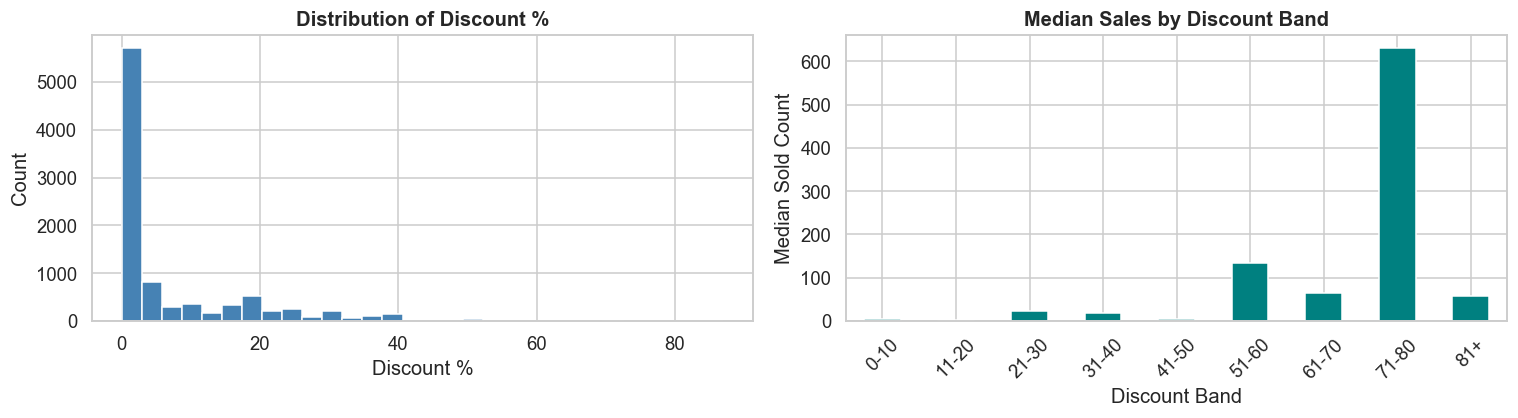

In [86]:
# Discount distribution 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
ax = axes[0]
ax.hist(product_df['discount_percent'].dropna(), bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Discount %')
ax.set_ylabel('Count')
ax.set_title('Distribution of Discount %', fontweight='bold')

# Avg sold_count by discount band
ax = axes[1]
bins   = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81+']
product_df['disc_band'] = pd.cut(product_df['discount_percent'], bins=bins, labels=labels)
avg_sold = product_df.groupby('disc_band', observed=True)['sold_count'].median()
avg_sold.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_xlabel('Discount Band')
ax.set_ylabel('Median Sold Count')
ax.set_title('Median Sales by Discount Band', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Many products do not have discount. In the discount products, 71 - 80% discount has the highest sold count.

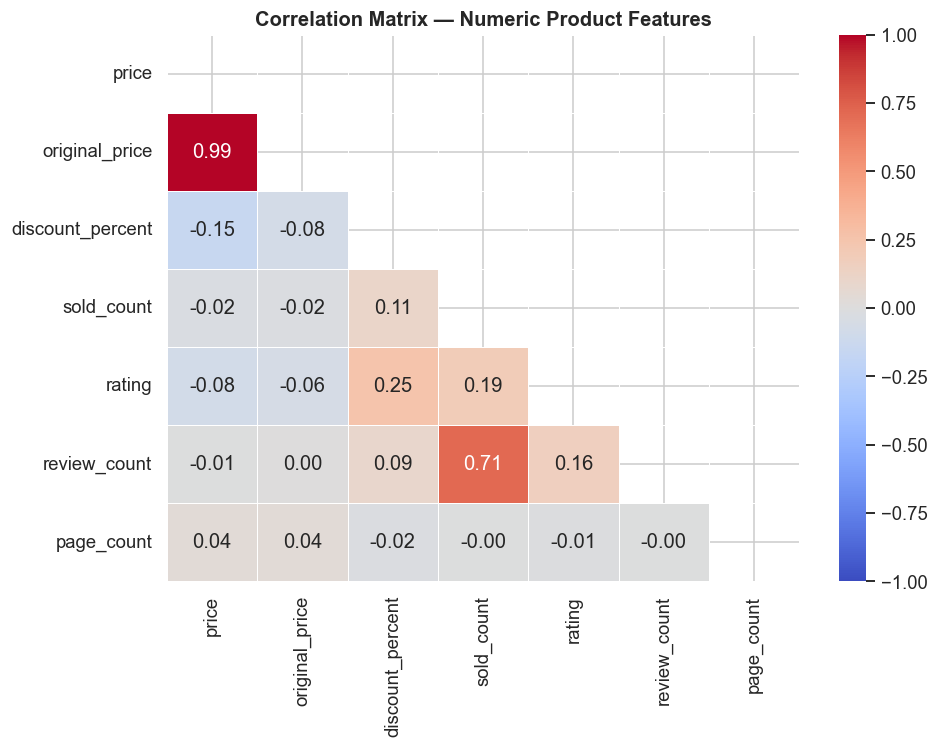

In [87]:
# Correlation matrix 
corr_cols = ['price', 'original_price', 'discount_percent', 'sold_count', 'rating', 'review_count', 'page_count']
corr_mat  = product_df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=.5, ax=ax
)
ax.set_title('Correlation Matrix — Numeric Product Features', fontweight='bold')
plt.tight_layout()
plt.show()

- There is a strong positive correlation between `sold_count` and `review_count`. This is a logical consumer behavior pattern: the more a book sells, the more reviews it accumulates. 
- As expected, `price` and `original_price` have an almost perfect positive correlation. This simply confirms that the final selling price scales linearly with the original price.
- The `page_count` feature shows near-zero correlation across the board. This reveals that the length of a book does not meaningfully influence its price, how heavily it is discounted, its rating, or how well it sells.
- There is a slight positive correlation (0.25) between `discount_percent` and `rating`, suggesting that buyers might be slightly more inclined to leave a higher rating when they feel they got a good deal. However, the correlation between `discount_percent` and `sold_count` is surprisingly weak (0.11), indicating that a steeper discount does not inherently guarantee higher overall sales volumes for these books.

### 3.2 Promotional Tactics — Combo & Gift Impact

Median sold_count and rating by promotional attributes:


sold_count       rating      
                      median count median count
is_combo has_gift                              
False    False           1.0  7468    0.0  7468
         True            0.0   159    0.0   159
True     False           1.0  1441    0.0  1441
         True            2.0   242    0.0   242

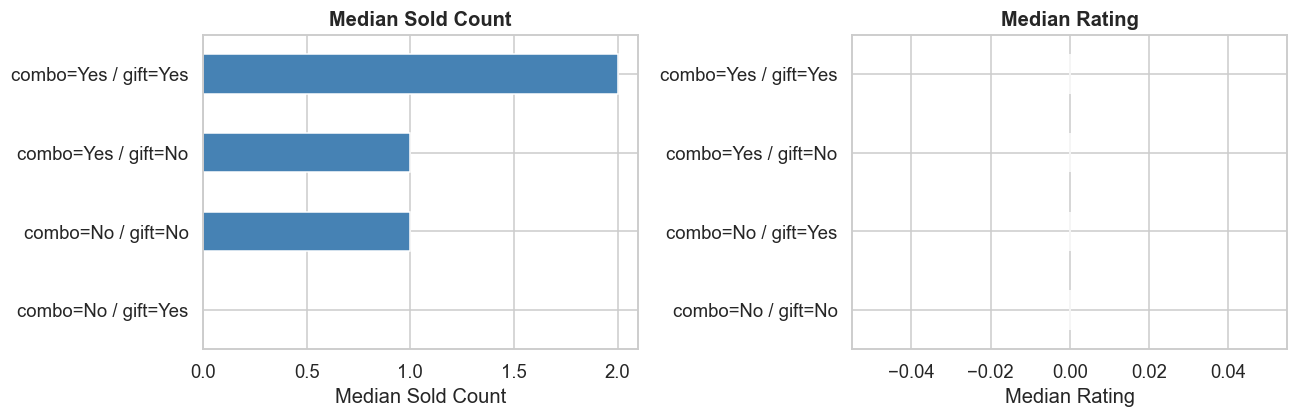

In [88]:
promo_stats = (
    product_df
    .groupby(['is_combo', 'has_gift'])[['sold_count', 'rating']]
    .agg(['median', 'count'])
    .round(2)
)
print('Median sold_count and rating by promotional attributes:')
display(promo_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['sold_count', 'rating'], ['Median Sold Count', 'Median Rating']):
    tbl = product_df.groupby(['is_combo', 'has_gift'], observed=True)[col].median().reset_index()
    tbl['group'] = tbl.apply(
        lambda r: f"combo={'Yes' if r.is_combo else 'No'} / gift={'Yes' if r.has_gift else 'No'}", axis=1
    )
    tbl.sort_values(col, ascending=True).plot(
        kind='barh', x='group', y=col, ax=ax, legend=False, color='steelblue', edgecolor='white'
    )
    ax.set_xlabel(title)
    ax.set_ylabel('')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

-> Combo + Gift has the highest median sold count

### 3.3 Category Analysis

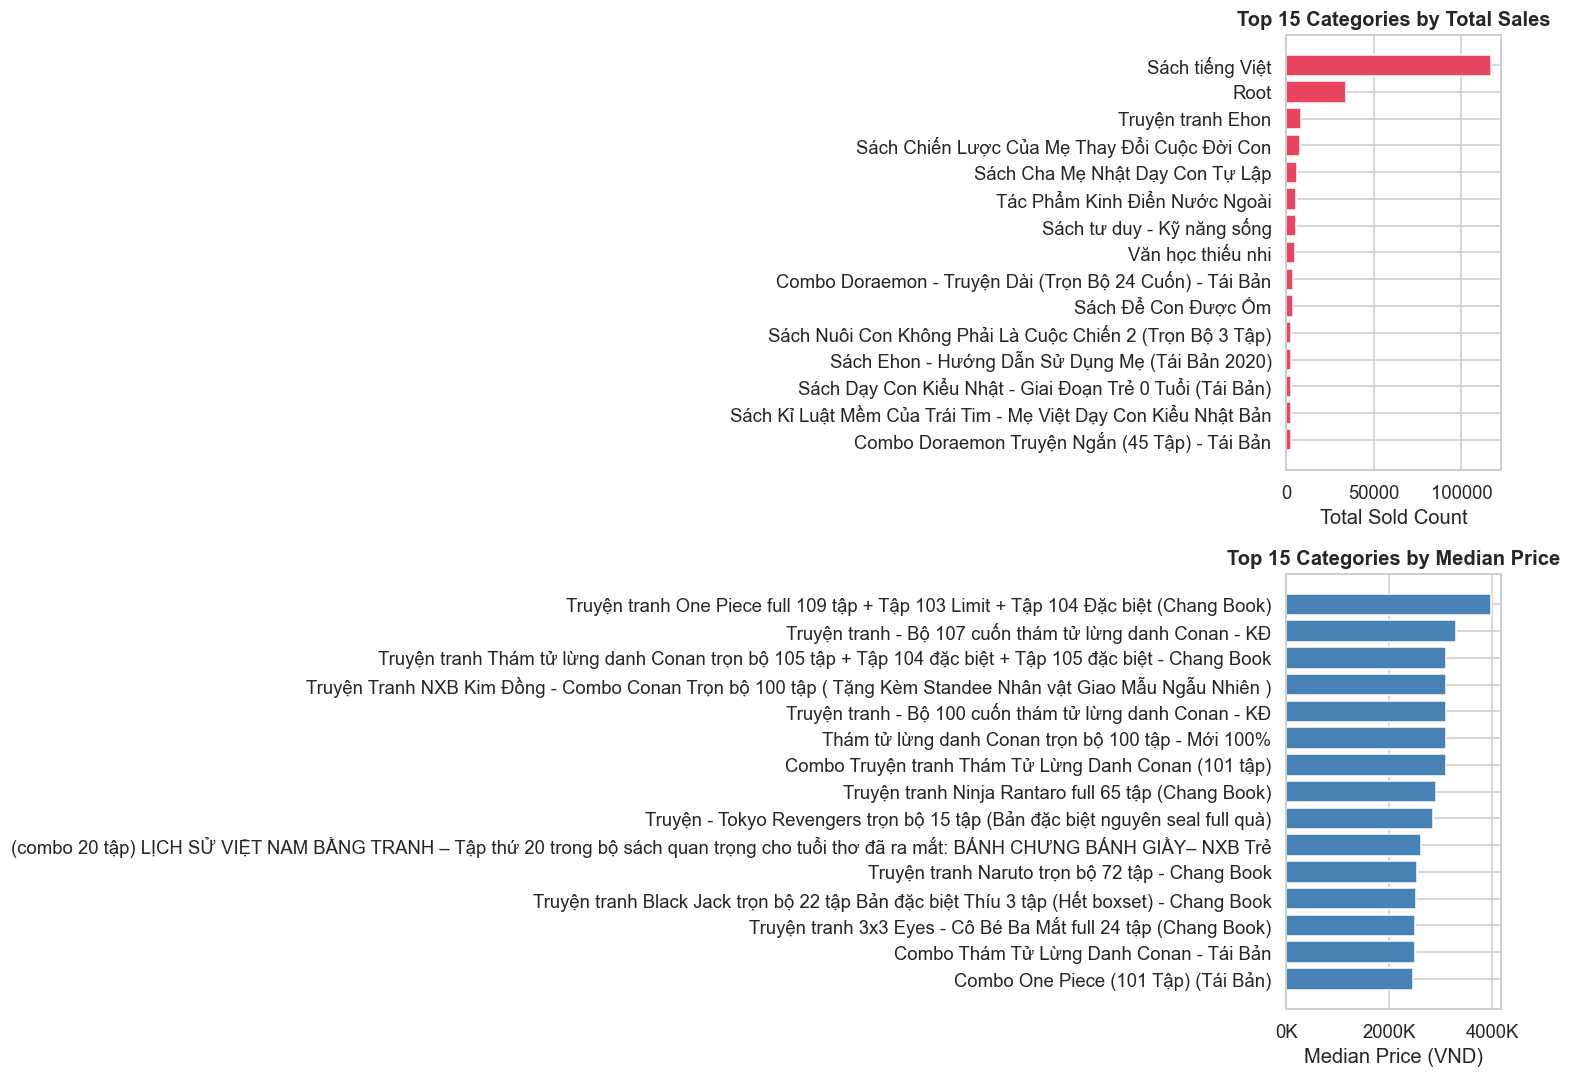

In [89]:
cat_stats = (
    product_df.groupby('category', observed=True)
    .agg(
        num_books   = ('product_id', 'count'),
        total_sales = ('sold_count', 'sum'),
        avg_price   = ('price', 'median'),
        avg_rating  = ('rating', 'mean'),
        bestsellers = ('is_bestseller', 'sum'),
    )
    .sort_values('total_sales', ascending=False)
)

TOP_N = 15

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Total sales by category
top_sales = cat_stats.head(TOP_N)
axes[0].barh(top_sales.index[::-1], top_sales['total_sales'][::-1], color=ACCENT, edgecolor='white')
axes[0].set_xlabel('Total Sold Count')
axes[0].set_title(f'Top {TOP_N} Categories by Total Sales', fontweight='bold')

# Avg price by category (top 15 most expensive)
top_price = cat_stats.sort_values('avg_price', ascending=False).head(TOP_N)
axes[1].barh(top_price.index[::-1], top_price['avg_price'][::-1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Median Price (VND)')
axes[1].set_title(f'Top {TOP_N} Categories by Median Price', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

"Sách tiếng Việt" are the best seller group. Comic books like One piece, Conan have the highest median price.

### 3.4 Publish Year Trend

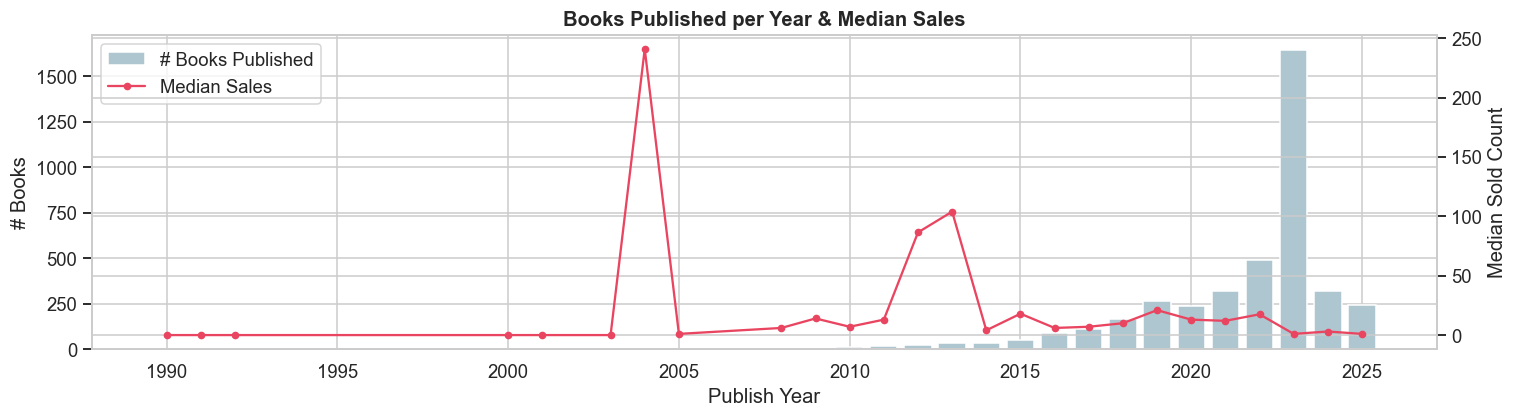

In [90]:
year_stats = (
    product_df.dropna(subset=['publish_year'])
    .assign(publish_year=lambda d: d['publish_year'].astype(int))
    .query('1990 <= publish_year <= 2025')   # reasonable range
    .groupby('publish_year')
    .agg(num_books=('product_id','count'), avg_sold=('sold_count','median'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.bar(year_stats['publish_year'], year_stats['num_books'], color='#aec6cf', label='# Books Published')
ax2.plot(year_stats['publish_year'], year_stats['avg_sold'], color=ACCENT, marker='o', ms=4, label='Median Sales')

ax1.set_xlabel('Publish Year')
ax1.set_ylabel('# Books')
ax2.set_ylabel('Median Sold Count')
ax1.set_title('Books Published per Year & Median Sales', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

From the 2023 to 2025, the median sales line has theFrom 2023 to 2025, the median sales line has the highest peak. There is also a lower peak from 2011 to 2025.  Specifically, the number of published books increases from 2025 to 2025 and reaches the top point at 2023. But the median sales are not high. highest peak. There is also a lower sp

## 4. Author Performance Analysis <a id='4'></a>

### 4.1 Quality vs. Quantity

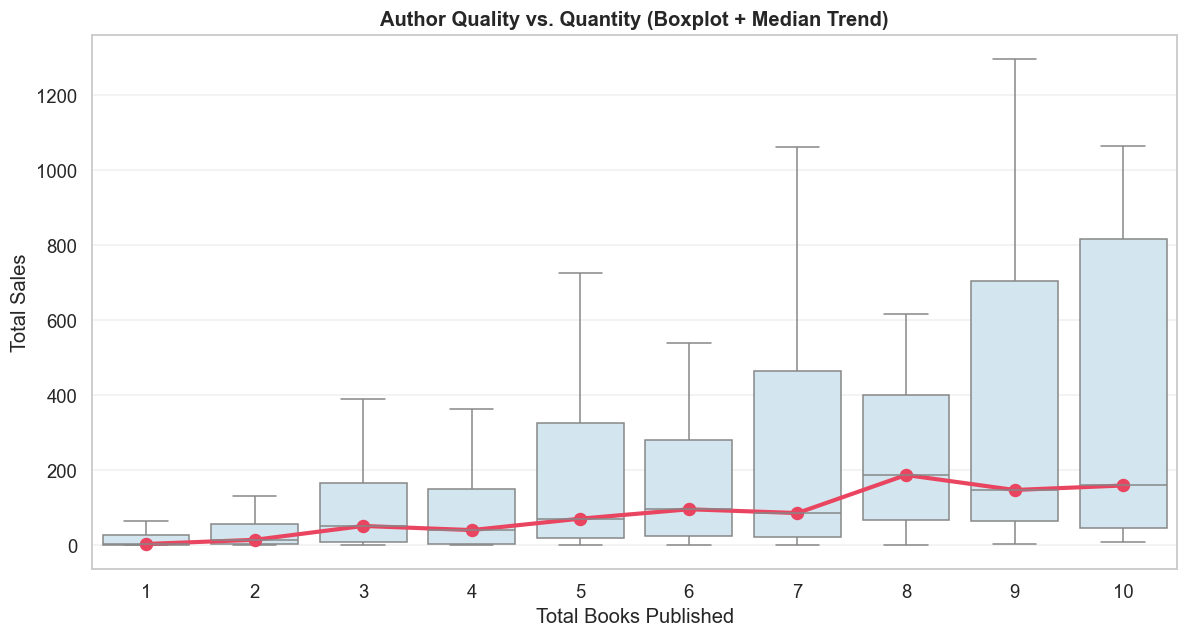

In [91]:
# Extreme outliers (the top 1%) have been removed to improve the readability of the main cluster.
q99_books = author_df['total_books'].quantile(0.99)
q99_sales = author_df['total_sales'].quantile(0.99)

plot_auth = author_df[
    (author_df['total_books'] <= q99_books) &
    (author_df['total_sales'] <= q99_sales)
].copy()

# keep only x-groups with enough samples (stable boxplots)
min_n = 8
book_freq = plot_auth['total_books'].value_counts()
valid_books = sorted(book_freq[book_freq >= min_n].index)

plot_box = plot_auth[plot_auth['total_books'].isin(valid_books)].copy()
plot_box['total_books'] = plot_box['total_books'].astype(int)

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=plot_box,
    x='total_books',
    y='total_sales',
    showfliers=False,
    color='#cfe8f3',
    ax=ax
)

# overlay median trend
sns.pointplot(
    data=plot_box,
    x='total_books',
    y='total_sales',
    estimator=np.median,
    errorbar=None,
    color=ACCENT,
    markers='o',
    linestyles='-',
    ax=ax
)

ax.set_xlabel('Total Books Published')
ax.set_ylabel('Total Sales')
ax.set_title('Author Quality vs. Quantity (Boxplot + Median Trend)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- Median sales generally increase as authors publish more books.
- The spread (IQR + whiskers) gets much wider at higher book counts (5–10), meaning outcomes are more uncertain for prolific authors.
- The median is not strictly increasing, so “more books” helps on average but is not guaranteed.

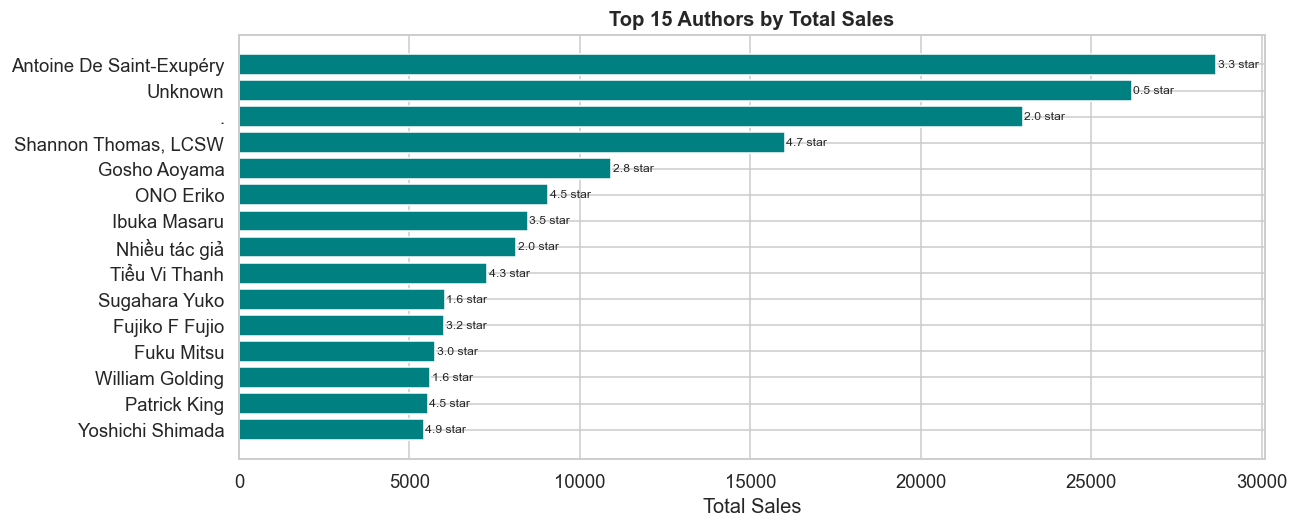

In [92]:
# Top 15 authors by total_sales
top_authors = author_df.nlargest(15, 'total_sales')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_authors['author_name'][::-1], top_authors['total_sales'][::-1],
               color='teal', edgecolor='white')
# overlay average rating as text
for bar, (_, row) in zip(bars, top_authors[::-1].iterrows()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{row["average_rating"]:.1f} star', va='center', fontsize=8)
ax.set_xlabel('Total Sales')
ax.set_title('Top 15 Authors by Total Sales', fontweight='bold')
plt.tight_layout()
plt.show()

There is an author named "Unknown" which has There is an author named "Unknown" who has the top 2 in the total sales.the top 2 in total sales by author.

### 4.2 Publisher Insights

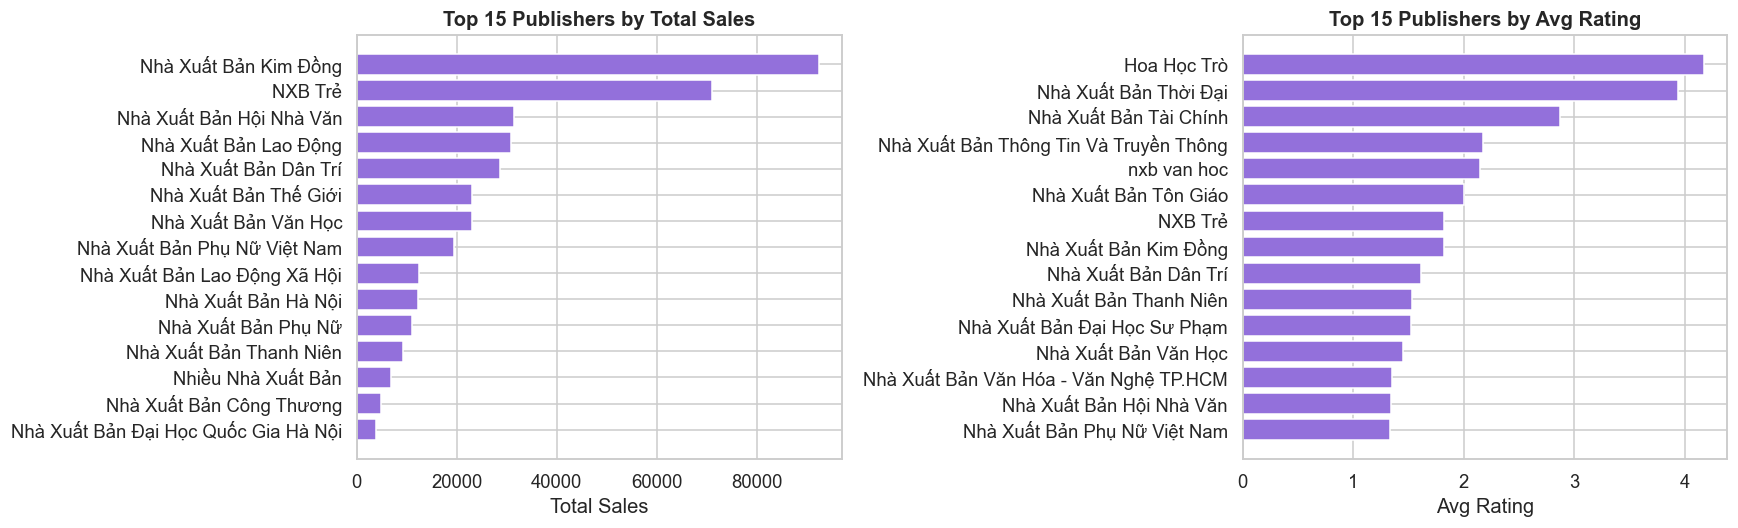

In [93]:
pub_stats = (
    product_df.dropna(subset=['publisher'])
    .groupby('publisher')
    .agg(
        num_titles  = ('product_id', 'count'),
        total_sales = ('sold_count', 'sum'),
        avg_sold    = ('sold_count', 'median'),
        avg_rating  = ('rating', 'mean'),
        bestsellers = ('is_bestseller', 'sum'),
    )
    .query('num_titles >= 5')   # meaningful publishers
    .sort_values('total_sales', ascending=False)
)

TOP_P = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(
    axes,
    ['total_sales', 'avg_rating'],
    [f'Top {TOP_P} Publishers by Total Sales', f'Top {TOP_P} Publishers by Avg Rating']
):
    top_pub = pub_stats.sort_values(metric, ascending=False).head(TOP_P)
    ax.barh(top_pub.index[::-1], top_pub[metric][::-1], color='mediumpurple', edgecolor='white')
    ax.set_xlabel(title.split(' by ')[1])
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

"Nhà Xuất Bản Kim Đồng" and "NXB Trẻ" have the largest total sales, but the best publishers by rating are "Hoa Học Trò", "Nhà Xuất Bản Thời Đại". 

## 5. Customer Sentiment & Review Analysis <a id='5'></a>

### 5.1 Rating Distribution

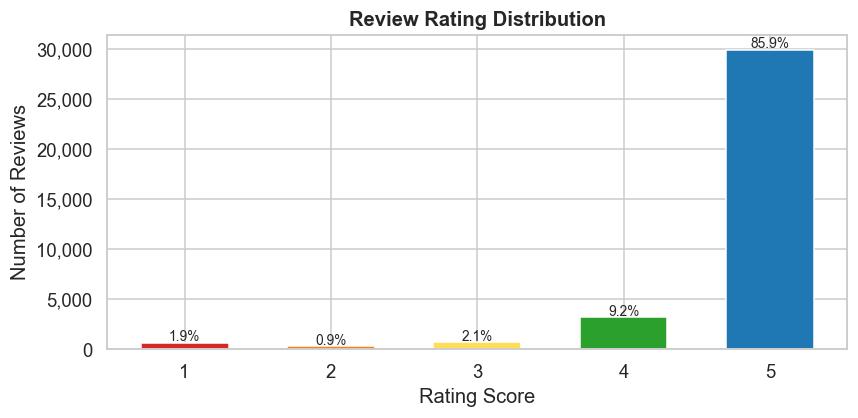


Mean rating : 4.764
Median rating: 5.0
5-star share : 85.9%


In [94]:
rating_counts = review_df['rating_score'].value_counts().sort_index()
pct           = (rating_counts / rating_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
bars    = ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', width=0.6)

for bar, p in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{p}%', ha='center', fontsize=9)

ax.set_xlabel('Rating Score')
ax.set_ylabel('Number of Reviews')
ax.set_title('Review Rating Distribution', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

print(f'\nMean rating : {review_df["rating_score"].mean():.3f}')
print(f'Median rating: {review_df["rating_score"].median():.1f}')
print(f'5-star share : {pct.get(5.0, 0):.1f}%')

The E-commerce ratings are heavily skewed towards 5-stars.

### 5.2 Review Length vs. Rating

Review length statistics by rating score (text reviews only):


,median,mean,count
rating_score,,,
1.0,87.0,133.589704,641
2.0,97.0,141.638095,315
3.0,84.0,142.085271,645
4.0,67.0,135.379935,1545
5.0,50.0,92.140829,11482


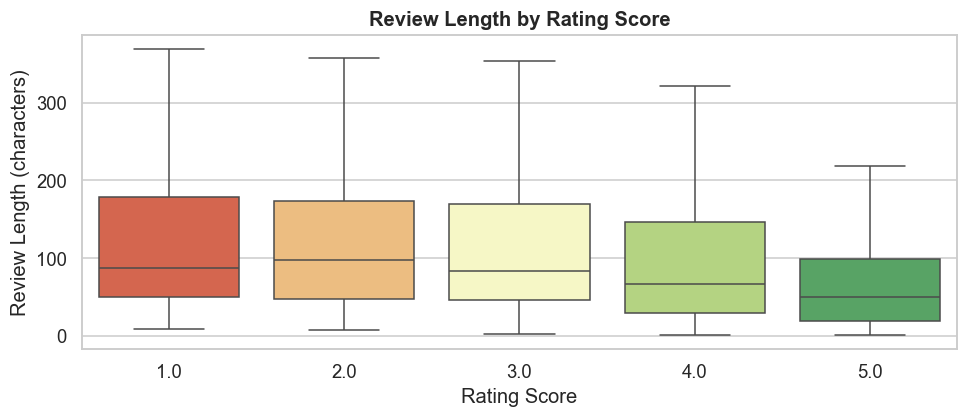

In [95]:
review_df['content_len'] = review_df['content'].fillna('').str.len()

# Only reviews that actually have text
text_reviews = review_df[review_df['content_len'] > 0]

len_by_rating = text_reviews.groupby('rating_score')['content_len'].agg(['median', 'mean', 'count'])
print('Review length statistics by rating score (text reviews only):')
display(len_by_rating)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(
    data=text_reviews,
    x='rating_score', y='content_len',
    palette='RdYlGn',
    showfliers=False, ax=ax
)
ax.set_xlabel('Rating Score')
ax.set_ylabel('Review Length (characters)')
ax.set_title('Review Length by Rating Score', fontweight='bold')
plt.tight_layout()
plt.show()

The 5 star review has the shortest length. The others are slightly the same.

### 5.3 Basic Text Analysis — Word Frequency in Positive vs. Negative Reviews

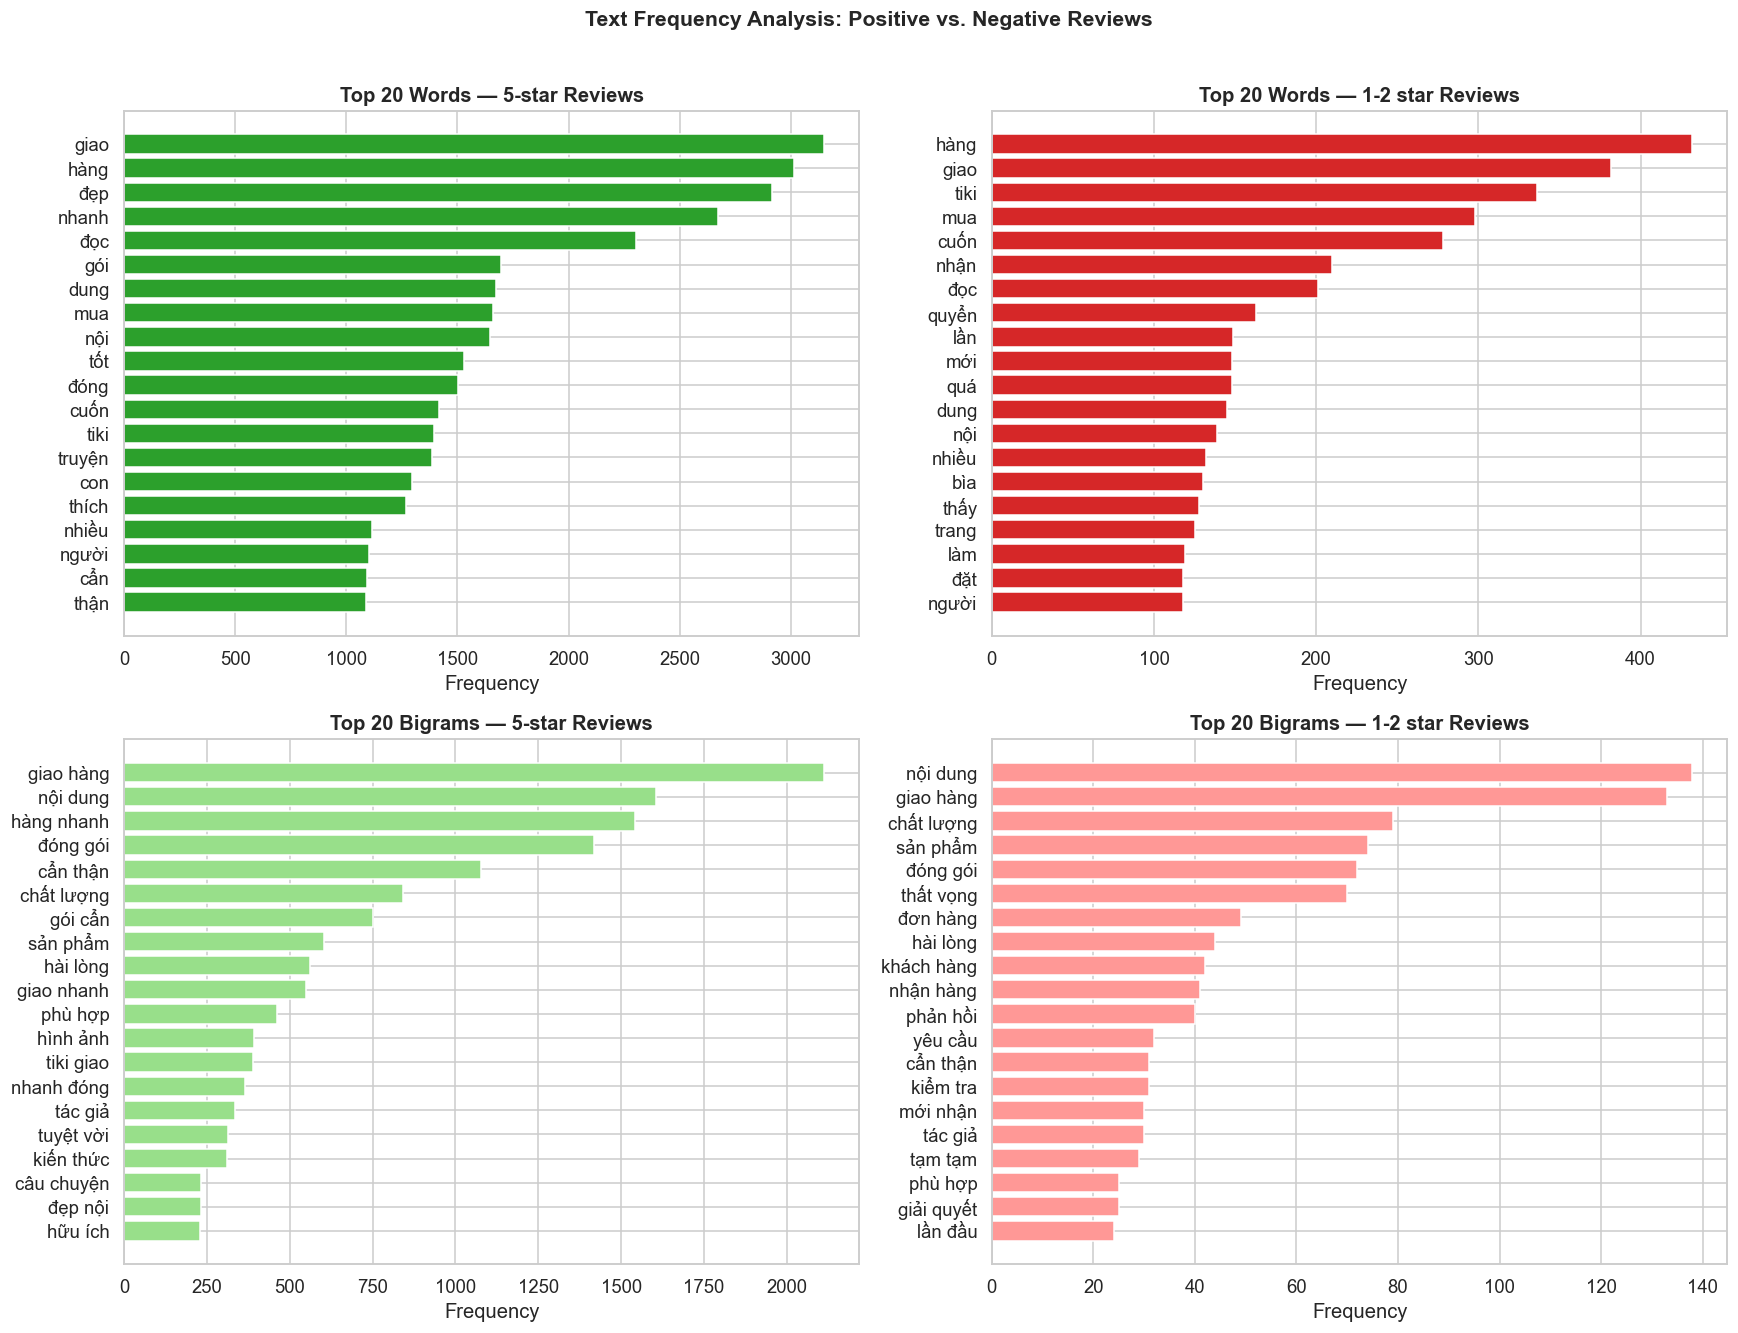

In [96]:
# Vietnamese stopwords
VI_STOPWORDS = {
    'và','của','là','có','được','cho','với','trong','này','không','đã','các',
    'một','rất','sách','như','nhưng','cũng','vì','khi','nên','mà','thì','còn',
    'hay','bị','tôi','mình','những','ra','để','lại','về','hơn','từ','theo',
    'đến','lên','chưa','được','có','thật','đây','nào','đó','ở','tại',
    'nan','nan','nan'
}

def tokenize(text: str) -> list[str]:
    if not isinstance(text, str):
        return []
    tokens = re.findall(r'[a-zA-ZÀ-ỹ]+', text.lower())
    return [t for t in tokens if t not in VI_STOPWORDS and len(t) > 2]

def bigrams(tokens: list[str]) -> list[str]:
    return [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens)-1)]

pos_reviews = review_df[review_df['rating_score'] == 5.0]['content'].dropna()
neg_reviews = review_df[review_df['rating_score'] <= 2.0]['content'].dropna()

pos_tokens = [tok for text in pos_reviews for tok in tokenize(text)]
neg_tokens = [tok for text in neg_reviews for tok in tokenize(text)]

pos_bigrams = [bg for text in pos_reviews for bg in bigrams(tokenize(text))]
neg_bigrams = [bg for text in neg_reviews for bg in bigrams(tokenize(text))]

TOP_K = 20

def plot_freq(counter, title, ax, color):
    top = pd.DataFrame(counter.most_common(TOP_K), columns=['term', 'count'])
    ax.barh(top['term'][::-1], top['count'][::-1], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_freq(Counter(pos_tokens),  f'Top {TOP_K} Words — 5-star Reviews',  axes[0,0], '#2ca02c')
plot_freq(Counter(neg_tokens),  f'Top {TOP_K} Words — 1-2 star Reviews', axes[0,1], '#d62728')
plot_freq(Counter(pos_bigrams), f'Top {TOP_K} Bigrams — 5-star Reviews', axes[1,0], '#98df8a')
plot_freq(Counter(neg_bigrams), f'Top {TOP_K} Bigrams — 1-2 star Reviews', axes[1,1], '#ff9896')

plt.suptitle('Text Frequency Analysis: Positive vs. Negative Reviews', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

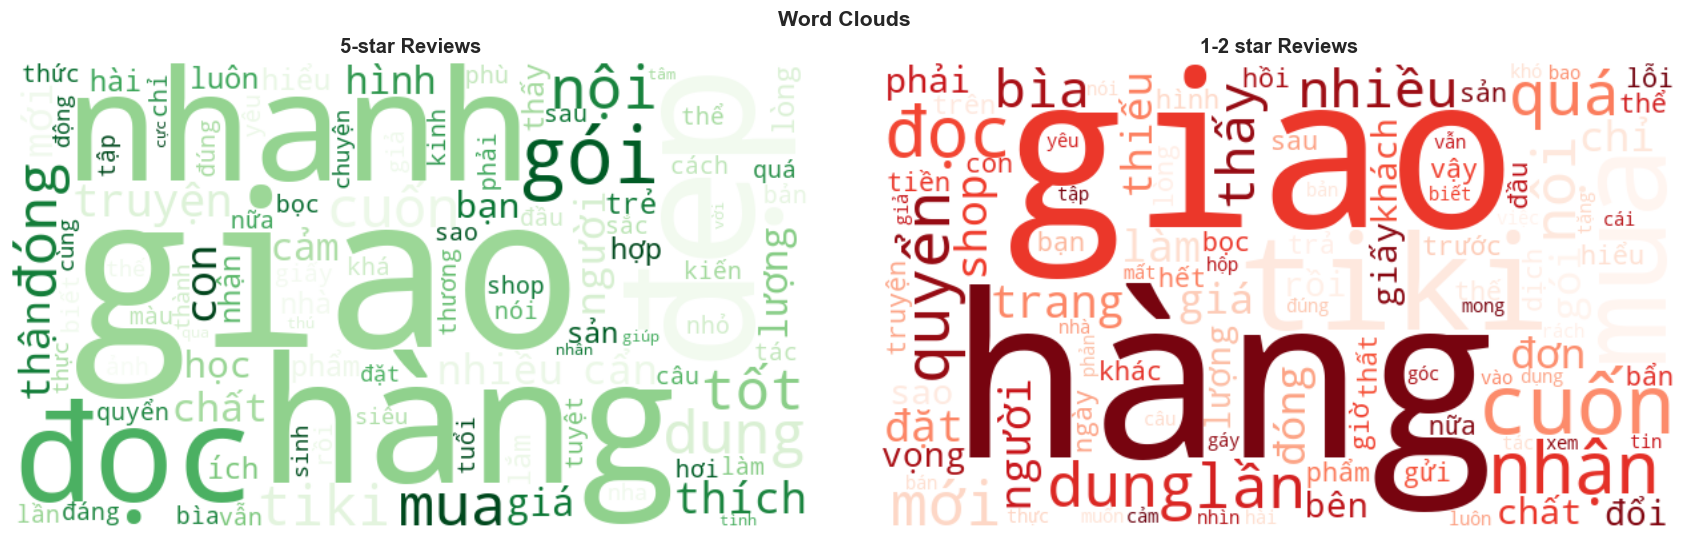

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, tokens, title, colormap in [
    (axes[0], pos_tokens, '5-star Reviews', 'Greens'),
    (axes[1], neg_tokens, '1-2 star Reviews', 'Reds'),
]:
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(' '.join(tokens))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold')
plt.suptitle('Word Clouds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Preprocessing <a id='6'></a>

### 6.1 Handle Missing Values

In [98]:
print(product_df.columns.tolist())

['product_id', 'title', 'price', 'original_price', 'discount_percent', 'sold_count', 'ranking', 'rating', 'review_count', 'author', 'publisher', 'category', 'publish_year', 'page_count', 'description', 'is_bestseller', 'is_top100', 'is_combo', 'has_gift', 'disc_band']


In [99]:
products_clean = product_df.copy()

# Numeric columns — fill with median
for col in ['publish_year', 'page_count']:
    med = products_clean[col].median()
    products_clean[col].fillna(med, inplace=True)
    print(f'{col}: filled {product_df[col].isnull().sum()} nulls with median={med:.1f}')

# Categorical columns — fill with 'Unknown'
for col in ['author', 'publisher', 'category', 'description']:
    n_null = products_clean[col].isnull().sum()
    products_clean[col].fillna('Unknown', inplace=True)
    print(f'{col}: filled {n_null} nulls with "Unknown"')

# Reviews — content can be empty
review_clean = review_df.copy()
review_clean['content'].fillna('', inplace=True)

print(f'\nRemaining nulls in products_clean: {products_clean.isnull().sum().sum()}')
print(f'Remaining nulls in review_clean  : {review_clean.isnull().sum().sum()}')

publish_year: filled 5121 nulls with median=2023.0
page_count: filled 4966 nulls with median=188.0
author: filled 2838 nulls with "Unknown"
publisher: filled 764 nulls with "Unknown"
category: filled 0 nulls with "Unknown"
description: filled 0 nulls with "Unknown"

Remaining nulls in products_clean: 18868
Remaining nulls in review_clean  : 20243


### 6.2 Data Type Conversion

In [100]:
# publish_year: float -> int
products_clean['publish_year'] = products_clean['publish_year'].astype('Int64')

# page_count: float -> int
products_clean['page_count'] = products_clean['page_count'].astype('Int64')

# Boolean columns: ensure bool dtype
bool_cols = ['is_bestseller', 'is_top100', 'is_combo', 'has_gift']
for col in bool_cols:
    products_clean[col] = products_clean[col].astype(bool)

# reviews — decode unix timestamp
review_clean['created_at'] = pd.to_datetime(review_clean['created_at'], unit='s')

print('products_clean dtypes:')
print(products_clean.dtypes)
print('\nreview_clean dtypes:')
print(review_clean.dtypes)

products_clean dtypes:
product_id             int64
title                    str
price                float64
original_price       float64
discount_percent       int64
sold_count             int64
ranking                int64
rating               float64
review_count           int64
author                   str
publisher                str
category                 str
publish_year           Int64
page_count             Int64
description              str
is_bestseller           bool
is_top100               bool
is_combo                bool
has_gift                bool
disc_band           category
dtype: object

review_clean dtypes:
review_id               int64
product_id              int64
rating_score          float64
content                   str
created_at      datetime64[s]
content_len             int64
dtype: object


### 6.3 Clean and remove HTML tag

In [101]:
HTML_TAG_RE = re.compile(r"<[^>]+>")
WHITESPACE_RE = re.compile(r"\s+")

for column in products_clean.select_dtypes(include=["object", "string"]).columns:
  normalized = products_clean[column].astype("string")
  normalized = normalized.map(lambda value: pd.NA if pd.isna(value) else unescape(str(value)))
  if column == "description":
    normalized = normalized.str.replace(HTML_TAG_RE, " ", regex=True)
  normalized = normalized.str.replace("\x00", " ", regex=False)
  normalized = normalized.str.replace(r"\s+", " ", regex=True).str.strip()
  products_clean[column] = normalized.replace("", pd.NA)

print(products_clean['description'].head())

0    Iacocca – Đời kinh doanh, Bí mật phía sau thàn...
1    Combo Sách Kinh Tế: Kinh Tế Học - Khái Lược Nh...
2    Tác giả Shlomo Maital Người Dịch Anh Tú NXB NX...
3    Sách Kinh Tế -Kinh Doanh Hay - Lý Thuyết Trò C...
4    Khách Hàng Thật Sự Cần Gì? “Việc cốt lõi ma...
Name: description, dtype: str


### 6.4 One-Hot Encoding

In [102]:
# One-hot encode 'category' 
# Keep top N categories to avoid a very wide sparse matrix
TOP_CAT = 20
top_cats = products_clean['category'].value_counts().head(TOP_CAT).index.tolist()
products_clean['category_binned'] = products_clean['category'].where(
    products_clean['category'].isin(top_cats), other='Other'
)

products_ohe = pd.get_dummies(
    products_clean,
    columns=['category_binned'],
    prefix='cat',
    drop_first=False,
    dtype=int
)

new_cols = [c for c in products_ohe.columns if c.startswith('cat_')]
print(f'Added {len(new_cols)} one-hot category columns:')
print(new_cols)
print(f'\nproducts_ohe shape: {products_ohe.shape}')

Added 21 one-hot category columns:
['cat_Bài học kinh doanh', 'cat_Classic', 'cat_Dạy Con Những Bài Học Về Tiền Bạc', 'cat_Fiction - Literature', 'cat_Khen Sao Cho Đúng, Mắng Sao Cho Chuẩn - Nuôi Dạy Một Đứa Trẻ Tự Lập Theo Phương Pháp Giáo Dục Montessori Và Reggio Emilia', 'cat_Kiến thức - Bách khoa', 'cat_Other', 'cat_Root', 'cat_Sách chuyên đề', 'cat_Sách kinh tế học - khác', 'cat_Sách kỹ năng sống', 'cat_Sách tham khảo cấp I', 'cat_Sách tham khảo cấp II', 'cat_Sách tham khảo cấp III', 'cat_Sách thiếu nhi', 'cat_Sách tiếng Việt', 'cat_Sách tư duy - Kỹ năng sống', 'cat_Truyện tranh thiếu nhi', 'cat_Tác Phẩm Kinh Điển Nước Ngoài', 'cat_Văn học thiếu nhi', 'cat_Đạo đức - Kỹ năng sống']

products_ohe shape: (9310, 41)


In [103]:
print(products_clean['category_binned'].unique().tolist())

['Root', 'Sách tiếng Việt', 'Other', 'Bài học kinh doanh', 'Sách kinh tế học - khác', 'Sách tư duy - Kỹ năng sống', 'Sách kỹ năng sống', 'Tác Phẩm Kinh Điển Nước Ngoài', 'Fiction - Literature', 'Classic', 'Sách tham khảo cấp I', 'Đạo đức - Kỹ năng sống', 'Truyện tranh thiếu nhi', 'Kiến thức - Bách khoa', 'Văn học thiếu nhi', 'Sách thiếu nhi', 'Sách tham khảo cấp II', 'Sách tham khảo cấp III', 'Sách chuyên đề', 'Khen Sao Cho Đúng, Mắng Sao Cho Chuẩn - Nuôi Dạy Một Đứa Trẻ Tự Lập Theo Phương Pháp Giáo Dục Montessori Và Reggio Emilia', 'Dạy Con Những Bài Học Về Tiền Bạc']


### 6.4 Standardization

Z-score scaled features (first 3 rows):


,price_z,original_price_z,discount_percent_z,sold_count_z,rating_z,review_count_z,page_count_z
0,0.174159,0.343572,1.208262,-0.056474,1.712707,-0.064999,0.051741
1,3.359017,3.205053,-0.612644,-0.116241,-0.604001,-0.096081,NaN
2,0.157438,0.110661,-0.612644,-0.121222,-0.604001,-0.096081,NaN



Min-Max scaled features (first 3 rows):


,price_mm,original_price_mm,discount_percent_mm,sold_count_mm,rating_mm,review_count_mm,page_count_mm
0,0.044982,0.056480,0.229885,0.000963,1.0,0.000568,0.001616
1,0.208270,0.208270,0.000000,0.000074,0.0,0.000000,NaN
2,0.044125,0.044125,0.000000,0.000000,0.0,0.000000,NaN


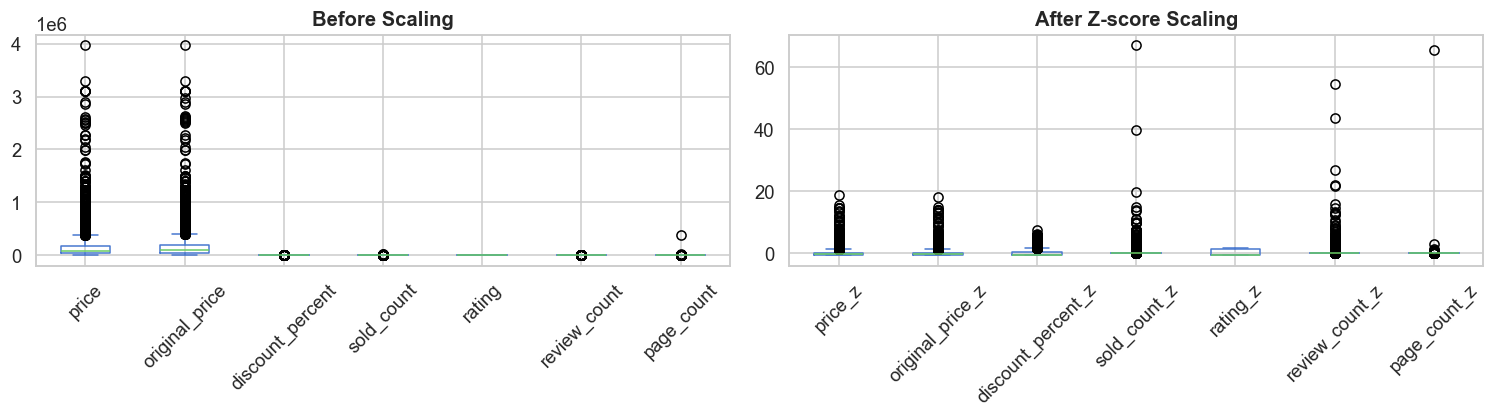

In [104]:
num_cols = ['price', 'original_price', 'discount_percent',
            'sold_count', 'rating', 'review_count', 'page_count']

scaler = StandardScaler()
scaled_arr = scaler.fit_transform(products_clean[num_cols])
scaled_df  = pd.DataFrame(scaled_arr, columns=[c + '_z' for c in num_cols],
                           index=products_clean.index)

print('Z-score scaled features (first 3 rows):')
display(scaled_df.head(3))

# Also show min-max for reference
mm_scaler = MinMaxScaler()
mm_arr = mm_scaler.fit_transform(products_clean[num_cols])
mm_df  = pd.DataFrame(mm_arr, columns=[c + '_mm' for c in num_cols],
                       index=products_clean.index)

print('\nMin-Max scaled features (first 3 rows):')
display(mm_df.head(3))

# Visualise before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
products_clean[num_cols].plot(kind='box', ax=axes[0], rot=45)
axes[0].set_title('Before Scaling', fontweight='bold')
scaled_df.plot(kind='box', ax=axes[1], rot=45)
axes[1].set_title('After Z-score Scaling', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 Export Cleaned Datasets

In [105]:
os.makedirs('../data/processed', exist_ok=True)

products_clean.to_csv('../data/processed/products_clean.csv', index=False)
review_clean.to_csv('../data/processed/reviews_clean.csv', index=False)
author_df.to_csv('../data/processed/authors_clean.csv', index=False)

print('Saved:')
print(f'  ../data/processed/products_clean.csv  — {products_clean.shape}')
print(f'  ../data/processed/reviews_clean.csv   — {review_clean.shape}')
print(f'  ../data/processed/authors_clean.csv   — {author_df.shape}')

Saved:
  ../data/processed/products_clean.csv  — (9310, 21)
  ../data/processed/reviews_clean.csv   — (34871, 6)
  ../data/processed/authors_clean.csv   — (2184, 4)
